In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'browser'
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "svg" # або "png"

In [2]:
df = pd.read_csv('supply_chain_dataset1.csv')

In [3]:
df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(91250, 15)
Date                       datetime64[us]
SKU_ID                                str
Warehouse_ID                          str
Supplier_ID                           str
Region                                str
Units_Sold                          int64
Inventory_Level                     int64
Supplier_Lead_Time_Days             int64
Reorder_Point                       int64
Order_Quantity                      int64
Unit_Cost                         float64
Unit_Price                        float64
Promotion_Flag                      int64
Stockout_Flag                       int64
Demand_Forecast                   float64
dtype: object
Date                       0
SKU_ID                     0
Warehouse_ID               0
Supplier_ID                0
Region                     0
Units_Sold                 0
Inventory_Level            0
Supplier_Lead_Time_Days    0
Reorder_Point              0
Order_Quantity             0
Unit_Cost                  0
Unit_Price               

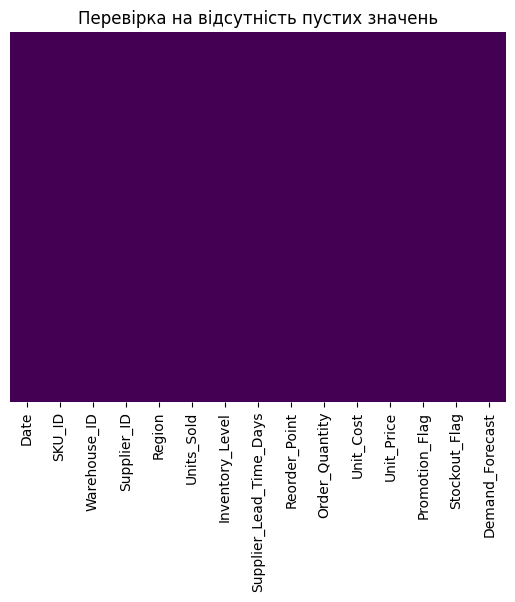

In [5]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Перевірка на відсутність пустих значень")
plt.show()

In [6]:
print(f"Унікальних товарів: {df['SKU_ID'].nunique()}")
print(f"Кількість регіонів: {df['Region'].nunique()}")

Унікальних товарів: 50
Кількість регіонів: 4


*Датасет чистий можна аналізувати*

**Розкладаю товар для наочного аналізу - Кількість продажів- Чистий прибуток - Регіон - відносно середніх показників**

In [7]:
df_map = df.copy()
df_map['net_price'] = df_map['Unit_Price'] - df_map['Unit_Cost']

df_filtered = df_map[df_map['Inventory_Level'] > df_map['Inventory_Level'].median()].copy()

fig = px.scatter(
    df_filtered, 
    x="net_price", 
    y="Units_Sold", 
    size="Inventory_Level", 
    color="Region",
    hover_name="SKU_ID",
    custom_data=["Region", "Inventory_Level"], 
    template="plotly_white",
    title="<b>Матриця Аналізу Товарів (Інтерактивна)</b>",
    labels={
        "net_price": "Прибуток ($)",
        "Units_Sold": "Продажі (од.)"
    }
)

fig.update_traces(
    marker=dict(opacity=0.6, line=dict(width=1, color='White')),
    hovertemplate="<b>Артикул: %{hovertext}</b><br><br>" +
                  "Прибуток: %{x:.2f}$<br>" +
                  "Продажі: %{y} од.<br>" +
                  "На складі: %{customdata[1]} од.<br>" +
                  "<b>Регіон: %{customdata[0]}</b><br>" + 
                  "<extra></extra>" 
)

fig.add_hline(y=df_filtered['Units_Sold'].mean(), line_dash="dash", line_color="blue", annotation_text="Сер. продажі")
fig.add_vline(x=df_filtered['net_price'].mean(), line_dash="dash", line_color="red", annotation_text="Сер. прибуток")

fig.show()

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


*На графіку можна побачити як товар розподіляється на своєрідній карті, яка показує, що асортимент і розподіл товару є великий, тобто у правому верхньому куті лідери продажів і кількостей, відповідно лівий нижній аутсайдери, залишки на складах і регіональний розподіл буде аналізуватися далі, бо на даному графіку нема очевидної відповіді*

**Дослідження прибутку і кількості продажів на часовому відрізку**

In [ ]:
df_sales = df.copy()
df_sales['revenue'] = (df_sales['Unit_Price'] - df_sales['Unit_Cost']) * df_sales['Units_Sold']
df_sales = df_sales.groupby('Date')[['revenue', 'Units_Sold']].sum().sort_values(by = 'Date', ascending=False).reset_index()
df_sales

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=df_sales['Date'], y=df_sales['revenue'], name="Прибуток ($)", line=dict(color='green', width=2)),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=df_sales['Date'], y=df_sales['Units_Sold'], name="Кількість (од.)", line=dict(color='yellow', width=4, dash='dot')),
    secondary_y=True,
)

fig.add_vline(x=pd.to_datetime('2024-03-25'), line_width=2, line_dash="dash", line_color="red")

fig.update_layout(
    title_text="<b>Динаміка прибутку та продажів за рік(Інтерактивна)</b>",
    template="plotly_white",
    hovermode="x unified"
)

fig.update_yaxes(title_text="<b>Прибуток</b> ($)", secondary_y=False)
fig.update_yaxes(title_text="<b>Кількість</b> (од.)", secondary_y=True)

fig.show()

*Графік показує стабільний і відносно прогнозований бізнес. Криві кількостей продажів і прибутку йдуть симетрично, відносно попиту працює пропозиція*

**Групування товарів і дослідження продажів по регіонах**

In [ ]:
df_regions = df.copy()
df_regions['revenue'] = (df_regions['Unit_Price'] - df_regions['Unit_Cost']) * df_regions['Units_Sold']
low_threshold = df['Unit_Price'].quantile(0.33)
high_threshold = df['Unit_Price'].quantile(0.66)

def categorize_price(price):
    if price <= low_threshold: return 'Budget'
    elif price <= high_threshold: return 'Medium'
    else: return 'Premium'

df_regions['Price_Category'] = df_regions['Unit_Price'].apply(categorize_price)
region_analysis = df_regions.groupby(['Region', 'Price_Category'])['revenue'].sum().unstack()
region_analysis['Premium_Share_%'] = (region_analysis['Premium'] / region_analysis.sum(axis=1) * 100).round(2)

region_analysis.sort_values(by='Premium_Share_%', ascending=False)

*Можна побачити дуже стабільний ринок. Продажі преміум сегменту перевищують 50% і різниця між регіоном North і West всього 1.37%, але цей регіон лідирує за середньосегментованими продажами. Як на мене це аномально, але може я помиляюся*

**Аналіз ефективності складів**

In [ ]:
df_warehouse = df.copy()
df_warehouse['revenue'] = (df_warehouse['Unit_Price'] - df_warehouse['Unit_Cost']) * df_warehouse['Units_Sold']
df_warehouse = df_warehouse = df_warehouse.groupby('Warehouse_ID').agg({
    'Inventory_Level': 'mean',
    'Reorder_Point': 'mean',
    'revenue': 'sum'
}).round(2)

df_warehouse.sort_values(by='revenue', ascending=False)

In [ ]:
df_warehouse['Revenue per Inventory Unit'] = round(df_warehouse['revenue']/df_warehouse['Inventory_Level'],1)
print("Прибуток складів на одиницю товару")
df_warehouse['Revenue per Inventory Unit'].sort_values(ascending = False)

*Можна побачити, що бажана кількість залишків для кожного складу є менша від реальної. Для ефективності складу провів додатковий розрахунок прибутку на одиницю товару і можна зробити висновок, що WH_1 має найменший дохід і різниця прибутку на одиницю від лідера становить 827.8$.*

**Аналіз логістики по регіонах**

In [ ]:
df_logistic = df.copy()
logistics_stats = df_logistic.groupby(['Supplier_ID', 'Region'])['Supplier_Lead_Time_Days'].agg(['median', 'std']).reset_index()

logistics_stats['Reliable_Time'] = (logistics_stats['median'] + logistics_stats['std']).round(2)

supply_matrix = logistics_stats.pivot(index='Supplier_ID', columns='Region', values='Reliable_Time')

supply_matrix['Avg_Reliability'] = supply_matrix.mean(axis=1).round(2)
supply_matrix = supply_matrix.sort_values(by='Avg_Reliability')

print("Матриця надійного часу доставки (Median + Std Dev):")
display(supply_matrix)

*Для аналізу середнього часу доставки створив змінну яка вираховується як медіанне значення плюс значення стандартного відхилення. Це зроблено, щоб врахувати форс-мажорні ситуаціїї. Перевізник SUP_5 очевидний лідер, а SUP_3 i SUP_2 аутсайдери. Також можна побачити певні регіональну турбулентність, наприклад SUB_8 працює швидше у регіонах EAST, North.*

**Пошук позитивних і негативних взаємозв'язків у датасеті**

In [ ]:
numeric_df = df.copy()
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df = numeric_df.drop(columns = ['Stockout_Flag'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt=".2f",          
    cmap='coolwarm',     
    center=0,            
    linewidths=0.5
)

plt.title('Теплова карта кореляції числових параметрів', fontsize=16)
plt.show()

*Стабільний прогнозований бізнес де прогноз попиту і кількість продажів сильно пов'язані. Також ціна товару залежить від його собівартості. Також можна оптимізувати залишки на складі відносно критичної кількості залишків.*